# <center>Metody Numeryczne</center>

# Laboratorium 9: Interpolacja


**Wykonał:** \<Łukasz Kopciński>

<br>

### **Metoda zaliczenia:**

Podczas zajęć należy wykonać poniższe polecenia oraz udzielić odpowiedzi na pytania zamieszczone w treści zadań. 

Wszystkie funkcje wymagane w ramach ćwiczenia należy zaimplementować w pliku `main.py`. Poprawność ich działania należy zweryfikować za pomocą testów jednostkowych dostępnych w pliku `test_main.py`.

### **Cel zajęć:**

Celem laboratorium jest praktyczne zapoznanie z zagadnieniem interpolacji wielomianowej, ze szczególnym uwzględnieniem jej wariantów numerycznie stabilnych. W ramach zajęć przeanalizowane zostanie działanie interpolacji barycentrycznej opartej na węzłach Czebyszewa.


### **Uwagi wstępne:**
- Funkcje wymagające implementacji (lub zaimplementowane na poprzednich laboratoriach) oznaczone są pochyłą czcionką maszynową (np. *`my_func()`*).

- W skrypcie stosuje się następujące skróty:

    - `np` - `numpy`,
    - `sp` - `scipy`.

---

In [12]:
# !python -m pip install numpy scipy matplotlib

import main

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import time

---

### **Zadanie 1.**

W celu wykonywania interpolacji należy przygotować funkcję wyliczającą wektor [węzłów Czebyszewa](https://en.wikipedia.org/wiki/Chebyshev_nodes) drugiego rodzaju (funkcja *`chebyshev_nodes()`*) dany wzorem:
  
$$
x_k = \cos\left(\cfrac{k\pi}{n}\right),\ \ \ k = 0,1,2,...,n
$$

oraz wagi barycentryczne dla tego typu wezłów (funkcja *`bar_cheb_weights()`*):

$$
\begin{align*}
    w_j={}&(-1)^j\delta_j\\
    \delta_j={}&
    \begin{cases}
        \frac{1}{2}, \quad j=\{0, n\}\\
        1, \quad j\in(0,n)
    \end{cases}
\end{align*}
$$


In [2]:
### IMPLEMENTACJA Z MAIN:
def chebyshev_nodes(n: int = 10) -> np.ndarray | None:
    
    if not (isinstance(n, (int, np.integer)) and n > 0):
        return None
    
    if n == 1:
        return np.array([1.0])

    nodes = np.ones(n)

    for k in range(len(nodes)):
        nodes[k] = np.cos(k * np.pi / (n - 1))

    return nodes    


def bar_cheb_weights(n: int = 10) -> np.ndarray | None:
   
    if not isinstance(n, (int, np.integer)) or n <= 0:
        return None

    if n == 1:
        return np.array([1.0])

    weights = np.ones(n)

    for k in range(n):
        weights[k] = (-1) ** k

    weights[0] *= 0.5
    weights[-1] *= 0.5

    return weights

---

### **Zadanie 2.**

Zaimplementuj podane funkcje, które będą używane w dalszej części laboratorium:

1. Ciągłą nieróżniczkowalną: $f_1(x) = \mathrm{sgn}(x)x+x^2$.

2. Różniczkowalną jednokrotnie: $f_2(x) = \mathrm{sgn}(x)x^{2}$.

3. Różniczkowalną trzykrotnie: $f_3(x)=|\sin(5 x)|^3$.

4. Trzy analityczne postaci: $f_{4a}(x) = \cfrac{1}{1+ax^2} \ $ dla $a \in \{1,25,100\}$. 

5. Nieciągłą: $f_5(x) = \mathrm{sgn}(x)$.

Funkcje można zaimplementować w notebooku lub w pliku `main.py`. 

>**Wskazówka:** Do definicji funkcji w notatniku można użyć [wyrażenia lambda](https://docs.python.org/3/tutorial/controlflow.html#lambda-expressions).
>
>$\mathrm{sgn}(x)$ to funkcja [signum](https://en.wikipedia.org/wiki/Sign_function).

In [3]:
# ===== Twoja implementacja tutaj =====
f1=lambda x: np.sign(x)*x +(x**2)

f2=lambda x: np.sign(x)*(x**2)

f3=lambda x: (abs(np.sin(5*x)))**3

f4= lambda x, a: 1/(1+a*(x**2))

f5=lambda x: np.sign(x) 

---

### **Zadanie 3.**

Do oceny jakości interpolacji stosuje się normę wektorową $\ell_{\infty}$. Dla różnicy wektorów definiujemy ją jako:  
  
$$
\ell_{\infty} = ||\mathbf{x_1}-\mathbf{x_2}||_\infty = \sup\{|\mathbf{x_1}-\mathbf{x_2}|\}
$$  
  
Zaimplementuj funkcję *`L_inf()`* wyznaczającą normę $\ell_{\infty}$. 


In [4]:
### IMPLEMENTACJA Z MAIN:

def L_inf(
    xr: int | float | list | np.ndarray, x: int | float | list | np.ndarray
) -> float | None:
 
    if isinstance(xr, (int, float, np.integer, np.floating)) and \
       isinstance(x,  (int, float, np.integer, np.floating)):
        return float(abs(xr - x))

 
    try:
        xr_arr = np.asarray(xr, dtype=float)
        x_arr = np.asarray(x, dtype=float)
    except Exception:
        return None

   
    if xr_arr.shape != x_arr.shape:
        return None

    if xr_arr.size == 0:
        return None

    return float(np.max(np.abs(xr_arr - x_arr)))

---

### **Zadanie 4.**

**Punkt 1.**

Zaimlementuj wzór barycentryczny podany na wykładzie jako funkcję *`barycentric_inte()`*.

<br>

**Punkt 2.**

Dla funkcji ciągłej nieróżniczkowalnej z **Zadania 2.** ($f_1(x)$) przeprowadź interpolację metodą [barycentryczną](https://people.maths.ox.ac.uk/trefethen/barycentric.pdf) zarówno przy użyciu funkcji [`sp.interpolate.barycentric_interpolate()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.barycentric_interpolate.html) jak i korzystając z zaimplementowanego wzoru barycentrycznego. 

W tym celu dla $n \in \{1, 2, 3, 4, 5\}$:

1. W węzłach Czebyszewa wykonaj interpolację rzędu $10^n$.

2. Wykreśl wykresy obrazujące wyniki interpolacji (wykres oryginalnej funkcji i funkcji interpolującej w $1000$ punktach).

3. Zbadaj jakość interpolacji za pomocą normy $\ell_{\infty}$.

Opisz jak zmieniały się wartość normy $\ell_{\infty}$ oraz czas obliczeń w zależności od rzędu interpolacji.


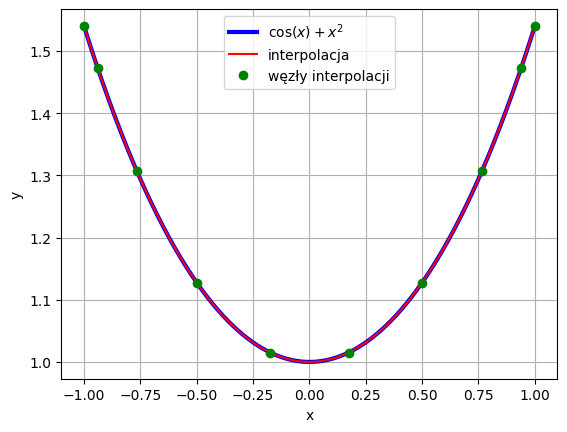

In [3]:
# Przykład użycia interpolacji barycentrycznej z wykorzystaniem węzłów Czebyszewa

# Funkcja do interpolacji
def f(x):
    return np.cos(x) + x**2

# Wektor współrzędnych, dla których chcemy wyliczyć wartości wielomianu interpolacyjnego
x = np.linspace(-1, 1, 1000)

# Węzły Czebyszewa
n = int(1e1)  # Liczba węzłów
xch = main.chebyshev_nodes(n)

# Interpoalcja
yimp = sp.interpolate.barycentric_interpolate(xch, f(xch), x)

plt.plot(x, f(x), 'b', linewidth=3, label=r'$\cos(x)+x^2$')
plt.plot(x, yimp, 'r', label='interpolacja')
plt.plot(xch, f(xch), 'go', label='węzły interpolacji')
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc=0)
plt.grid()
plt.show()

In [5]:
### IMPLEMENTACJA Z MAIN:
def barycentric_inte(
    xi: np.ndarray, yi: np.ndarray, wi: np.ndarray, x: np.ndarray
) -> np.ndarray | None:
    
    if not all(isinstance(arr, np.ndarray) for arr in (xi, yi, wi, x)):
        return None

    if xi.ndim != 1 or yi.ndim != 1 or wi.ndim != 1 or x.ndim != 1:
        return None

    if len(xi) == 0 or len(xi) != len(yi) or len(xi) != len(wi):
        return None

    result = np.zeros_like(x, dtype=float)

    for j in range(len(x)):
      
        diff = x[j] - xi
        zero_idx = np.where(np.isclose(diff, 0.0))[0]

        if zero_idx.size > 0:
            result[j] = yi[zero_idx[0]]
        else:
            numerator = np.sum(wi * yi / diff)
            denominator = np.sum(wi / diff)
            result[j] = numerator / denominator

    return result

In [17]:
# ===== Twoja implementacja tutaj =====
x=np.linspace(-1,1,1000)

ch1=chebyshev_nodes(10)
ch2=chebyshev_nodes(100)
ch3=chebyshev_nodes(1000)
ch4=chebyshev_nodes(10000)
ch5=chebyshev_nodes(100000)

bch1=bar_cheb_weights(10)
bch2=bar_cheb_weights(100)
bch3=bar_cheb_weights(1000)
bch4=bar_cheb_weights(10000)
bch5=bar_cheb_weights(100000)

tim1start=time.time()
y1=sp.interpolate.barycentric_interpolate(ch1,f1(ch1),x)
tim1end=time.time()

tim2start=time.time()
y2=sp.interpolate.barycentric_interpolate(ch2,f1(ch2),x)
tim2end=time.time()

tim3start=time.time()
y3=sp.interpolate.barycentric_interpolate(ch3,f1(ch3),x)
tim3end=time.time()

tim4start=time.time()
y4=sp.interpolate.barycentric_interpolate(ch4,f1(ch4),x)
tim4end=time.time()

tim5start=time.time()
y5=sp.interpolate.barycentric_interpolate(ch5,f1(ch5),x)
tim5end=time.time()


time11start=time.time()
y1w=barycentric_inte(ch1,f1(ch1),bch1,x)
time11end=time.time()

tim22start=time.time()
y2w=barycentric_inte(ch2,f1(ch2),bch2,x)
tim22end=time.time()

tim33start=time.time()
y3w=barycentric_inte(ch3,f1(ch3),bch3,x)
tim33end=time.time()

tim44start=time.time()
y4w=barycentric_inte(ch4,f1(ch4),bch4,x)
tim44end=time.time()

tim55start=time.time()
y5w=barycentric_inte(ch5,f1(ch5),bch5,x)
tim55end=time.time()




In [18]:
t1=tim1end-tim1start
t2=tim2end-tim2start
t3=tim3end-tim3start
t4=tim4end-tim4start
t5=tim5end-tim5start

t11=time11end-time11start
t22=tim22end-tim22start
t33=tim33end-tim33start
t44=tim44end-tim44start
t55=tim55end-tim55start

y_od_sp=[y1,y2,y3,y4,y5]

y_odemnie=[y1w,y2w,y3w,y4w,y5w]

ch_odemnie=[ch1,ch2,ch3,ch4,ch5]

n_odemnie=[10,100,1000,10000,100000]


In [25]:
time_vec_sp=np.array([t1,t2,t3,t4,t5])

time_vec_odemnie=np.array([t11,t22,t33,t44,t55])

Wartość n:  {10} 



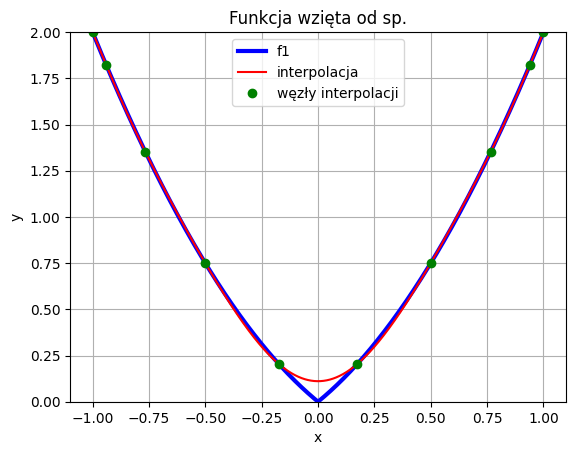

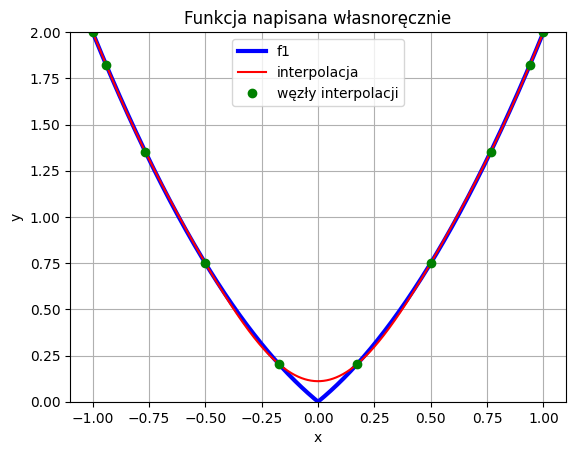

Wartość n:  {100} 



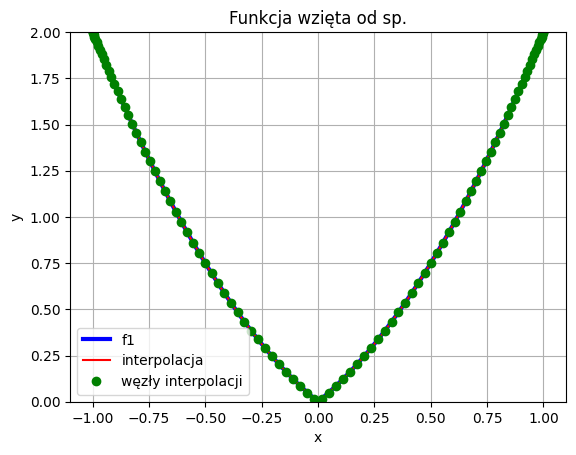

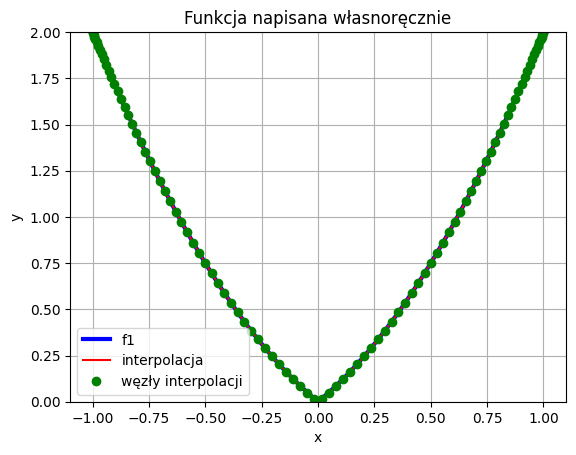

Wartość n:  {1000} 



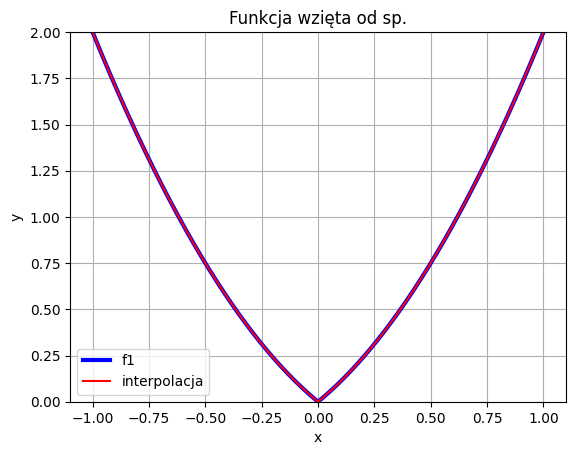

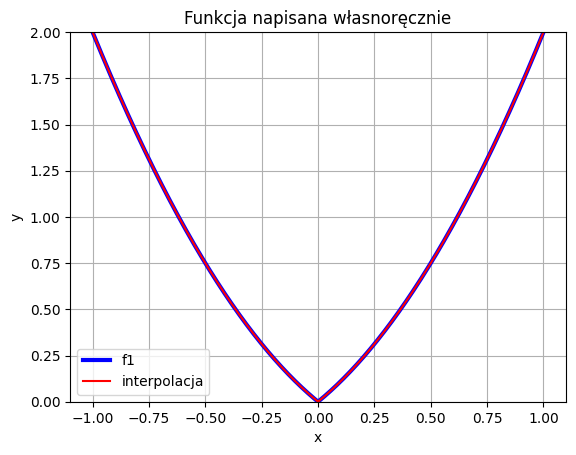

Wartość n:  {10000} 



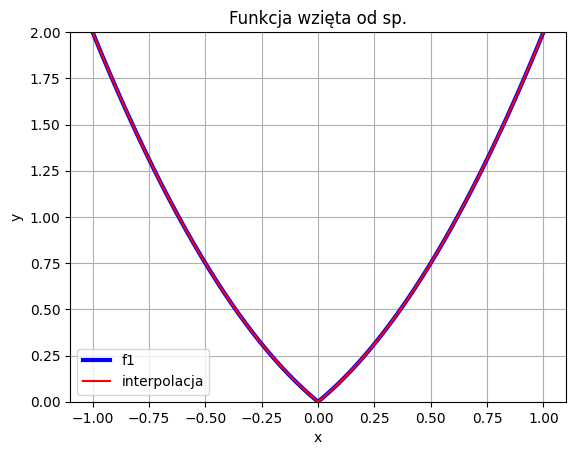

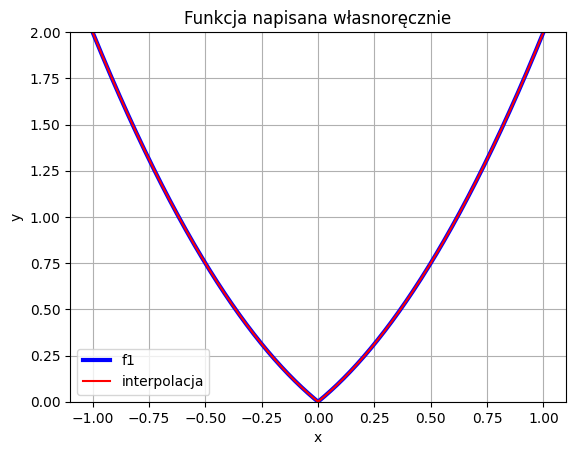

Wartość n:  {100000} 



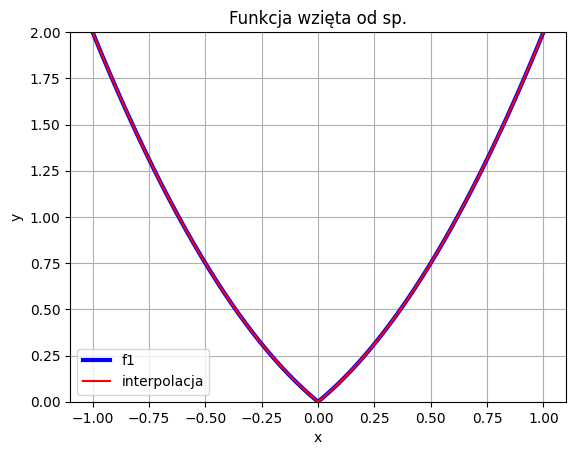

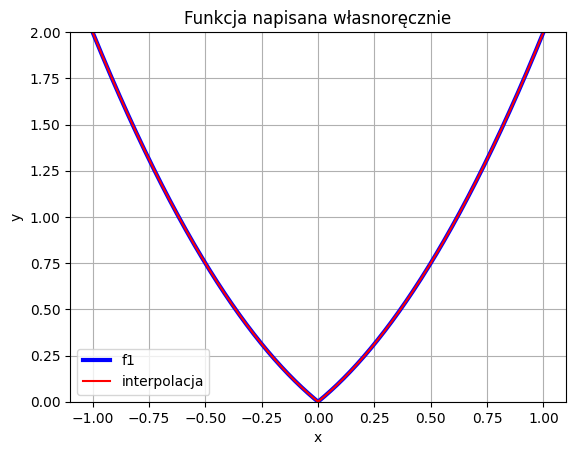

In [ ]:
for i in range(len(y_od_sp)):    
    
    print(f"Wartość n: ",{n_odemnie[i]},"\n")
    plt.figure()
    plt.plot(x, f1(x), 'b', linewidth=3, label=r'f1')
    plt.plot(x, y_od_sp[i], 'r', label='interpolacja')
    if i<=1:    
        plt.plot(ch_odemnie[i], f1(ch_odemnie[i]), 'go', label='węzły interpolacji')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(loc=0)
    plt.title("Funkcja wzięta od sp.")
    plt.ylim(0,2)
    plt.grid()
    plt.show()
    

    plt.figure()
    plt.plot(x, f1(x), 'b', linewidth=3, label=r'f1')
    plt.plot(x, y_odemnie[i], 'r', label='interpolacja')
    if i<=1:
        plt.plot(ch_odemnie[i], f1(ch_odemnie[i]), 'go', label='węzły interpolacji')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(loc=0)
    plt.title("Metoda barycentryczna napisana własnoręcznie")
    plt.ylim(0,2)
    plt.grid()
    plt.show()

Wykres wykonywania operacji dla obu implementacji



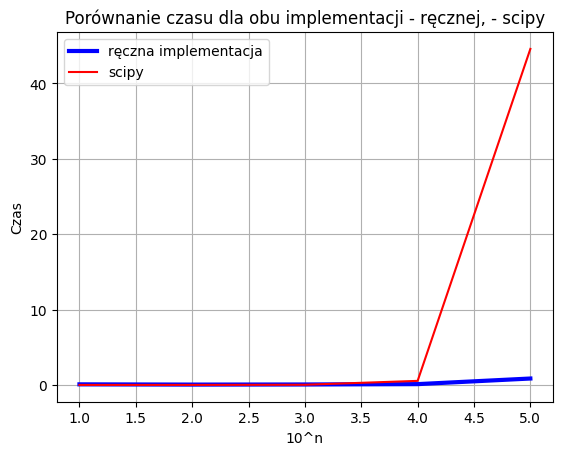

In [29]:
###WYKRES CZASU i dokladnosci
print(f"Wykres wykonywania operacji dla obu implementacji\n")

plt.figure()
plt.plot(np.array([1,2,3,4,5]), time_vec_odemnie, 'b', linewidth=3, label=r'ręczna implementacja')
plt.plot(np.array([1,2,3,4,5]), time_vec_sp, 'r', label='scipy')
plt.xlabel("10^n")
plt.ylabel("Czas")
plt.legend(loc=0)
plt.title("Porównanie czasu dla obu implementacji - ręcznej, - scipy")
plt.grid()
plt.show()


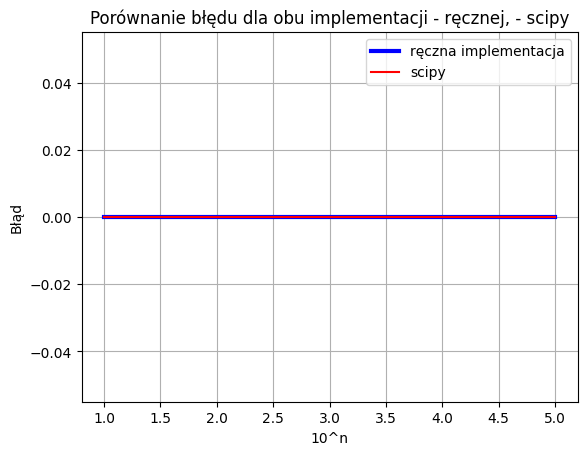

In [31]:
y_true=f1(x)
blad_sp=np.array([0,0,0,0,0])
blad_reczne=np.array([0,0,0,0,0])

for i in range(len(y_od_sp)):
    blad_sp[i]=np.max(np.abs(y_true-y_od_sp[i]))

    blad_reczne[i]=max(np.abs(y_true-y_odemnie[i]))

plt.figure()
plt.plot(np.array([1,2,3,4,5]), blad_sp, 'b', linewidth=3, label=r'ręczna implementacja')
plt.plot(np.array([1,2,3,4,5]), blad_reczne, 'r', label='scipy')
plt.xlabel("10^n")
plt.ylabel("Błąd")
plt.legend(loc=0)
plt.title("Porównanie błędu dla obu implementacji - ręcznej, - scipy")
plt.grid()
plt.show()

WNIOSKI:
- z przeprowadzonej analizy wykresów, wynika że zasadniczo od n=1000 wykres jest bardzo dokładny, nie ma wielkich odchyłem
- błąd dla obu implementacji był równy, wynosił zero

---

### **Zadanie 5.**

Dla funkcji jednokrotnie ($f_2(x)$) i trzykrotnie ($f_3(x)$) różniczkowalnych z **Zadania 2.** należy przeanalizować w pętli jakość interpolacji dla interpolacji rzędu $10^n$, gdzie $n \in \{1, 2, 3, 4, 5\}$. 

W tym celu:

1. Wylicz wartość funkcji i wielomianu interpolacyjnego w $1000$ punktów (nie będącymi węzłami interpolacji np. punkty równoodległe).

2. Wylicz normę różnicy tych wektorów (normę błędu) dla każdego badanego rzędu. Maksymalny rząd należy przyjąć gdy błąd będzie na poziomie zera maszynowego.

3. Dla każdej z funkcji sporządź wykres w skali podwójnie logarytmicznej (obie osie), w którym oś argumentów to rząd interpolacji a oś wartości to odpowiadająca mu norma błędu.

4. Dla porównania umieść na wykresie dodatkowo wykres $n^{-v}$, gdzie $v$ to rząd najwyższej pochodnej funkcji (zobacz wykład).


Analiza dla funkcji: f2


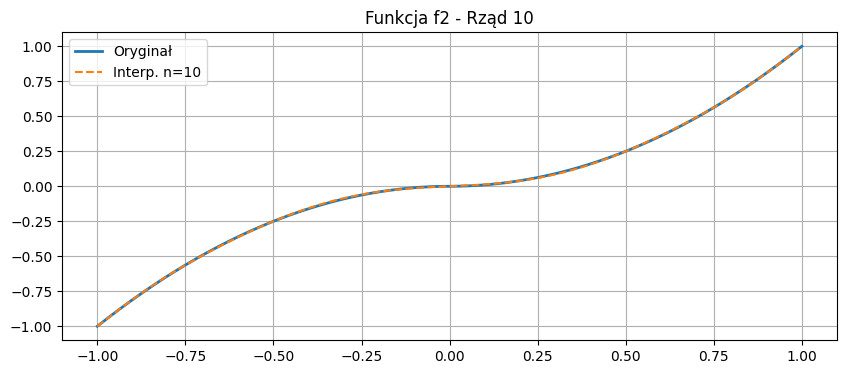

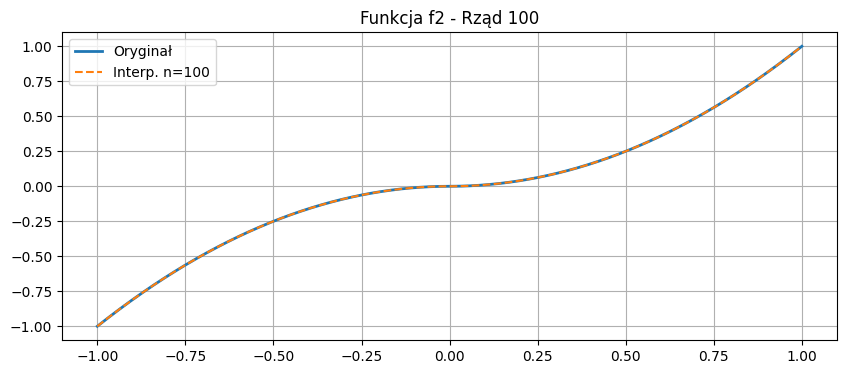

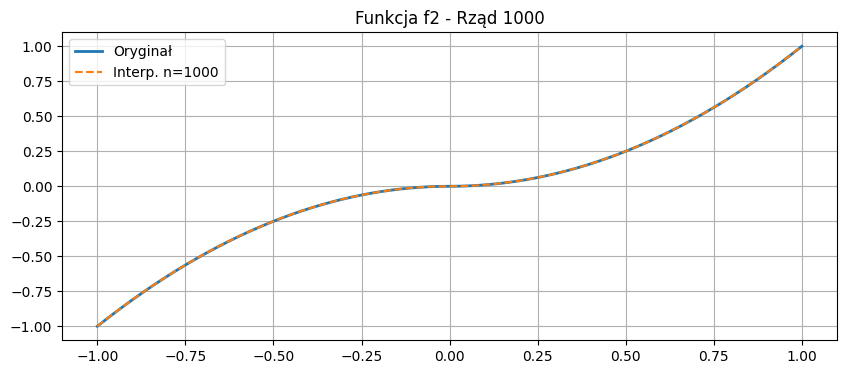

n: 10, Blad l: 5.30e-03, Czas w sekundach: 0.003416
n: 100, Blad l: 4.56e-05, Czas w sekundach: 0.002274
n: 1000, Blad l: 4.47e-07, Czas w sekundach: 0.028882
n: 10000, Blad l: 1.86e-09, Czas w sekundach: 0.490978
n: 100000, Blad l: 2.24e-12, Czas w sekundach: 59.535727

Analiza dla funkcji: f3


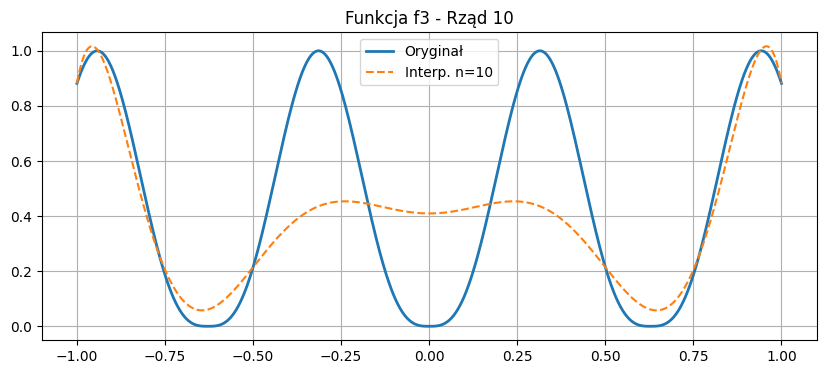

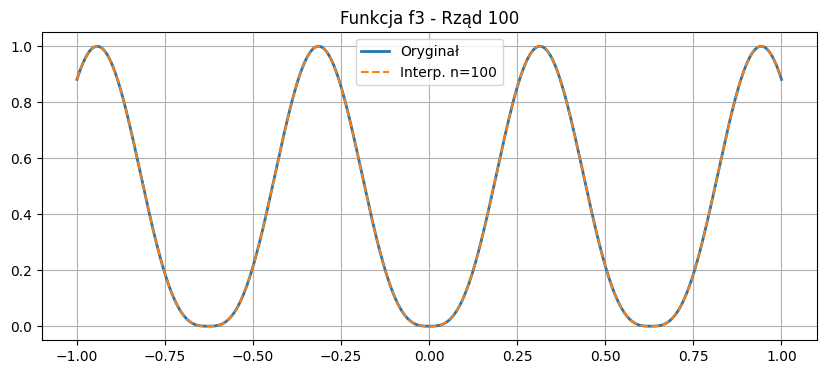

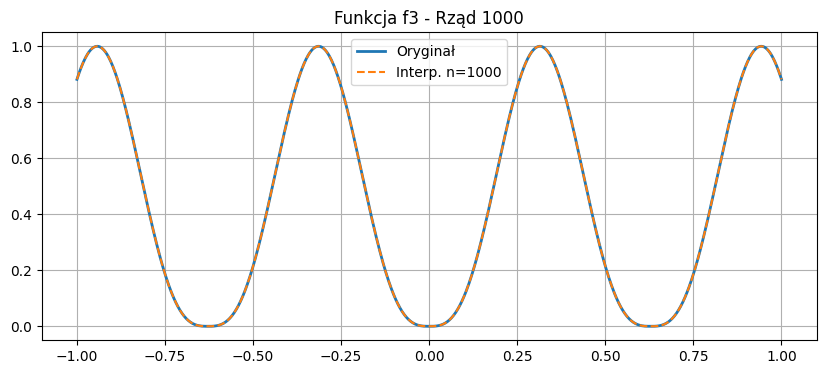

n: 10, Blad l: 5.66e-01, Czas w sekundach: 0.001483
n: 100, Blad l: 3.34e-04, Czas w sekundach: 0.003600
n: 1000, Blad l: 1.38e-07, Czas w sekundach: 0.021096
n: 10000, Blad l: 2.51e-11, Czas w sekundach: 0.498141
n: 100000, Blad l: 8.27e-15, Czas w sekundach: 81.305451


In [37]:
# ===== Twoja implementacja tutaj =====
import time

test_functions = {'f2': f2, 'f3': f3}
n_values = [10, 100, 1000, 10000, 100000]
x_test = np.linspace(-1, 1, 1000)

for name, func in test_functions.items():
    print(f"\nAnaliza dla funkcji: {name}")
    
    y_true = func(x_test)
    errors_sp = []
    times_sp = []
    
    for n in n_values:
        nodes = chebyshev_nodes(n)
        y_nodes = func(nodes)
        
        t0 = time.time()
        y_sp = sp.interpolate.barycentric_interpolate(nodes, y_nodes, x_test)
        times_sp.append(time.time() - t0)
        errors_sp.append(np.max(np.abs(y_true - y_sp)))
        
        if n <= 1000:
            plt.figure(figsize=(10, 4))
            plt.plot(x_test, y_true, label='Oryginał', linewidth=2)
            plt.plot(x_test, y_sp, '--', label=f'Interp. n={n}')
            plt.title(f"Funkcja {name} - Rząd {n}")
            plt.legend()
            plt.grid(True)
            plt.show()

    for i in range(len(n_values)):
        print(f"n: {n_values[i]}, Blad l: {errors_sp[i]:.2e}, Czas w sekundach: {times_sp[i]:.6f}")

---

### **Zadanie 6.**

Dla funkcji nieciągłej z **Zadania 2.** ($f_5(x)$) przeanalizować należy [efekt Gibbsa](https://en.wikipedia.org/wiki/Gibbs_phenomenon).

1. Oddzielnie dla parzystych i nieparzystych $n$ wylicz jaki jest minimalny błąd niezależny od rzędu. 

2. Odpowiedz dlaczego wartości dla parzystych i nieparzystych $n$ się różnią.

> **Wskazówka:** Wykonaj wykres funkcji i jej funkcji interpolującej.

Efekt Gibbsa dla f5
n_parzyste: 10, Blad: 0.9987 | n_nieparzyste: 11, Blad: 1.9991
n_parzyste: 20, Blad: 0.9972 | n_nieparzyste: 21, Blad: 1.9982
n_parzyste: 30, Blad: 0.9957 | n_nieparzyste: 31, Blad: 1.9973
n_parzyste: 40, Blad: 0.9942 | n_nieparzyste: 41, Blad: 1.9965
n_parzyste: 50, Blad: 0.9927 | n_nieparzyste: 51, Blad: 1.9956
n_parzyste: 60, Blad: 0.9912 | n_nieparzyste: 61, Blad: 1.9947
n_parzyste: 70, Blad: 0.9898 | n_nieparzyste: 71, Blad: 1.9938
n_parzyste: 80, Blad: 0.9883 | n_nieparzyste: 81, Blad: 1.9929
n_parzyste: 90, Blad: 0.9868 | n_nieparzyste: 91, Blad: 1.9920
n_parzyste: 100, Blad: 0.9853 | n_nieparzyste: 101, Blad: 1.9911


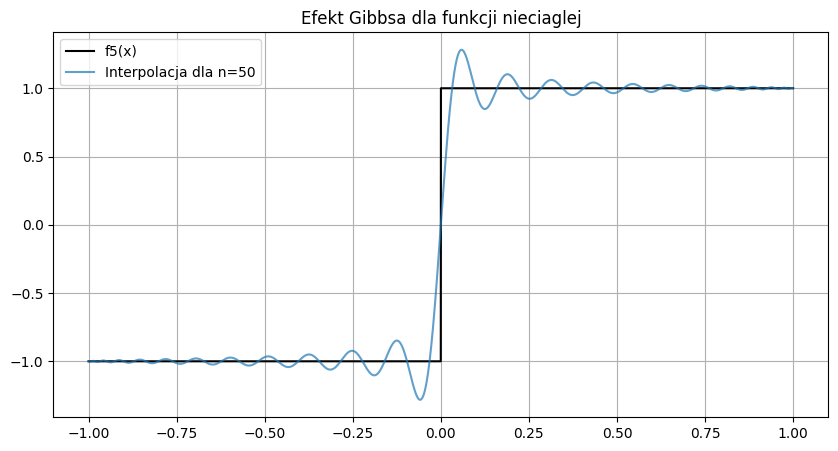

In [44]:
# ===== Twoja implementacja tutaj =====
import scipy.interpolate as interp

n_even = np.arange(10, 110, 10)
n_odd = np.arange(11, 111, 10)
x_test = np.linspace(-1, 1, 5000)
y_true = f5(x_test)

def get_gibbs_error(n_vals):
    errors = []
    for n in n_vals:
        nodes = chebyshev_nodes(n)
        y_nodes = f5(nodes)
        y_interp = interp.barycentric_interpolate(nodes, y_nodes, x_test)
        errors.append(np.max(np.abs(y_true - y_interp)))
    return errors

errors_even = get_gibbs_error(n_even)
errors_odd = get_gibbs_error(n_odd)

print(f"Efekt Gibbsa dla f5")
for i in range(len(n_even)):
    print(f"n_parzyste: {n_even[i]}, Blad: {errors_even[i]:.4f} | n_nieparzyste: {n_odd[i]}, Blad: {errors_odd[i]:.4f}")

plt.figure(figsize=(10, 5))
nodes_sample = chebyshev_nodes(50)
y_interp_sample = interp.barycentric_interpolate(nodes_sample, f5(nodes_sample), x_test)
plt.plot(x_test, y_true, label='f5(x)', color='black')
plt.plot(x_test, y_interp_sample, label='Interpolacja dla n=50', alpha=0.7)
plt.title("Efekt Gibbsa dla funkcji nieciaglej")
plt.legend()
plt.grid(True)
plt.show()

WNIOSKI:
- dla n parzystych, więzły czybyszewa są rozmieszczone symetrycznie i żaden z nich nie leży w pkt 0.
- dla n nieparzystych środek leży w pkt 0.
- w tym przypadku błąd l nie dąży do 0 wraz ze wrzostem n.

---

**Materiały uzupełniające:**
- [Scipy Lecture Notes](http://www.scipy-lectures.org/index.html)
- [NumPy for Matlab users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#numpy-for-matlab-users)
- [Python Tutorial - W3Schools](https://www.w3schools.com/python/default.asp)
- [NumPy](https://www.numpy.org)
- [Matplotlib](https://matplotlib.org/)
- [Anaconda](https://www.anaconda.com/)
- [Learn Python for Data Science](https://www.datacamp.com/learn-python-with-anaconda?utm_source=Anaconda_download&utm_campaign=datacamp_training&utm_medium=banner)
- [Learn Python](https://www.learnpython.org/)
- [Wujek Google](https://google.pl) i [Ciocia Wikipedia](https://pl.wikipedia.org/wiki/Wikipedia:Strona_g%C5%82%C3%B3wna)